# 03 — Saturation versus Paper greedy: measured flash reads

Use Notebook 01's measured lookup table and Notebook 02's full-width Qwen importance vectors. Compare only **Paper greedy** and **Saturation**, using the upstream native selectors and six-thread `O_DIRECT` reader. Report 30 repetitions, medians and 95% BCa intervals.

The measured boundary is **prepared CPU importance → selection → selected bytes on CPU**, including reader preparation. The traces contain no weights or full activations for matrix multiplication: this is a projection-read experiment, not full-model inference. Retained importance is a quality proxy, not task accuracy.

Set `RUN_BENCHMARK = True` for fresh reads; normal execution reads the saved measured files. The old `selection_results.csv` and `environment.json` belong to the earlier 207 KiB, three-method CPU experiment and are not reused.

In [47]:
from pathlib import Path
from time import perf_counter_ns
from tempfile import TemporaryDirectory
import hashlib, json, os, platform, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROFILE, MODEL = Path("../01/block_estimates.csv"), Path("../01/latency_model.json")
TRACE, UPSTREAM = Path("../02/activation_traces.npz"), Path("../../../upstream/vlm-flash")
RESULTS, ENVIRONMENT = Path("measured_results.csv"), Path("measured_environment.json")
RUN_BENCHMARK = True
MAX_TRACES_PER_SHAPE = 32
FRACTIONS = np.arange(3, 11) / 10  # paper sparsity 0.7 ... 0.0
WARMUP, REPEATS, THREADS = 3, 30, 6

## Set the tile width from Notebook 01

Take the median over all seven profile blocks and minimize cost per KiB:
$$z_{\rm eff}=\arg\min_z T(z)/z,\qquad B=\lceil z_{\rm eff}/w\rceil.$$
The saved result is **240 KiB**, distinct from the fitted breakpoint (207 KiB) and the 99% crossing (233 KiB).

Paper keeps 02's shape-specific windows and 99%-crossing ceiling. Both methods now use the **measured lookup table** for utility, as in the paper. Saturation keeps 02's two offsets, best disjoint residual and merged-run utility comparison, with the new width above. Old oracle gaps and masks therefore do not transfer to this experiment. Upstream interpolation, sub-KiB flooring and linear extrapolation beyond the table are used for selection/diagnostics only.

In [48]:
profile = pd.read_csv(PROFILE)
curve = profile.groupby("size_kib").latency_ms.median().sort_index()
boundary = float((curve / curve.index).idxmin())
model = json.loads(MODEL.read_text())
assert hashlib.sha256(PROFILE.read_bytes()).hexdigest() == model["csv_sha256"]
assert boundary == model["s_eff_kib"]
display(pd.Series({"Tile boundary (KiB)": boundary,
    "Paper ceiling (KiB)": model["s99_kib"], "Fitted breakpoint (unused)": model["s_kib"]}))

Tile boundary (KiB)           240.0
Paper ceiling (KiB)           233.0
Fitted breakpoint (unused)    207.0
dtype: float64

## Prepare the shared native path

Paper enables GPU sorting when CUDA is available; the environment records the actual setting. CPU-only results are local measurements, not Jetson GPU-sort reproduction. Static geometry is outside timing for both methods.

A random blob is physically written and fsynced on this notebook's filesystem. Each mask uses its original projection row-byte width. Contents do not affect selection or serve as model weights. The unchanged reader merges adjacent rows, splits tasks at 768 KiB, and reads with six threads. Buffered fallback is rejected.

In [49]:
if RUN_BENCHMARK:
    import torch
    from torch.utils.cpp_extension import load
    os.environ.setdefault("MAX_JOBS", "1")
    torch.set_num_threads(1)
    sys.path[:0] = [str((UPSTREAM / p).resolve()) for p in ("scripts", "src")]
    import vlmflash
    from vlmflash._native import native
    from vlmflash.policy import _window_sweep
    from profile_flash import write_blob, exclusive
    assert Path(vlmflash.__file__).resolve().is_relative_to(UPSTREAM.resolve())
    reader = native()
    assert reader is not None, "Build the upstream native extension first."
    selectors = load("vlmflash_selection03", [str(Path("selectors.cpp").resolve())],
                     extra_cflags=["-O3", "-std=c++17"], verbose=False)
    table, cuda_sort = vlmflash.LatencyTable(curve.to_dict()), torch.cuda.is_available()
    with np.load(TRACE, allow_pickle=False) as archive:
        manifest = json.loads(str(archive["manifest_json"].item()))
        traces = [{**t, "values": archive[t["array"]]} for t in manifest["traces"]]
    groups = [[t for t in traces if t["shape"] == shape] for shape in sorted({t["shape"] for t in traces})]
    traces = [g[i] for g in groups for i in np.linspace(0, len(g)-1,
              min(len(g), MAX_TRACES_PER_SHAPE or len(g)), dtype=int)]
    weight_bytes = {"float16": 2, "bfloat16": 2, "float32": 4}[manifest["model_dtype"]]
    geometry = {"896x128": (8,8), "896x896": (8,8), "896x4864": (8,8), "4864x896": (12,16)}

## Measure selection and actual reads in the same repetition

Use three warm-up rounds, then 30 measured rounds with randomly interleaved methods. The outer clock measures selection through reader return; native `io_ms` is a nested read/thread interval. Validation is outside timing. No sum of component medians is used.

Saturation fills exactly $R=\lfloor fN\rfloor$; Paper may underfill, so actual counts and importance are recorded. At full retention both use the same all-ones mask, matching the dense baseline. Neither GPU upload nor compute is included.

In [50]:
if RUN_BENCHMARK:
    rng, records = np.random.default_rng(0), []
    with exclusive("03_paper_saturation"), TemporaryDirectory(dir=RESULTS.parent) as work:
        blob = str(Path(work) / "rows.dat")
        write_blob(blob, max(t["n"] * t["d"] * weight_bytes for t in traces))
        for index, trace in enumerate(traces, 1):
            v = trace["values"].astype(np.float32)
            v = v / v.mean() if v.any() else v
            values, N = torch.from_numpy(v), len(v)
            row_bytes = weight_bytes * trace["d"]
            w, (start, jump) = row_bytes / 1024, geometry[trace["shape"]]
            B = int(np.ceil(boundary / w))
            costs = torch.tensor([0.] + [table.read_ms(w*r) for r in range(1, N+1)], dtype=torch.float64)
            params = vlmflash.ChunkParams(start_kb=start, step_kb=start, jump_cap_kb=jump,
                                          end_kb=model["s99_kib"]+1)
            windows, stride = _window_sweep(N, w, table, params)
            sizes = torch.tensor([r for r, _ in windows], dtype=torch.int64)
            delays = torch.tensor([t for _, t in windows], dtype=torch.float64)
            for fraction in FRACTIONS:
                R, dense = max(1, int(round(float(fraction), 6)*N)), torch.ones(N, dtype=torch.uint8)
                functions = {
                    "Paper greedy": lambda: reader.select_chunks(values, R, sizes, delays, stride, cuda_sort)[0],
                    "Saturation": lambda: selectors.tiles(values, R, costs, B)[0]}
                checked = {}
                for name, fn in functions.items():
                    mask = dense if R == N else fn()
                    selected = int(mask.sum())
                    assert selected <= R if name == "Paper greedy" else selected == R
                    spans = np.flatnonzero(np.diff(np.r_[False, mask.numpy().astype(bool), False])).reshape(-1,2)
                    checked[name] = (mask.clone(), dict(R_selected=selected, fill_pct=100*selected/R,
                        retained_pct=100*float(values[mask.bool()].double().sum())/float(values.double().sum()),
                        modeled_io_ms=float(costs[np.diff(spans).ravel()].sum()), runs=len(spans),
                        intervals=json.dumps(spans.tolist())))
                for repeat in range(-WARMUP, REPEATS):
                    for name in rng.permutation(list(functions)):
                        begin = perf_counter_ns()
                        mask = dense if R == N else functions[name]()
                        after_select = perf_counter_ns()
                        raw, io_us, _, direct = reader.read_rows(blob, mask, row_bytes, "cpu", THREADS, 768*1024, True)
                        end = perf_counter_ns()
                        assert direct, "O_DIRECT unavailable; refusing page-cache timings."
                        assert torch.equal(mask, checked[name][0])
                        assert raw.shape == (checked[name][1]["R_selected"], row_bytes)
                        if repeat >= 0:
                            records.append(dict(trace_id=trace["trace_id"], shape=trace["shape"],
                                fraction=float(fraction), R_nominal=R, tile_rows=B, method=name, repeat=repeat,
                                selection_ms=(after_select-begin)/1e6, io_ms=io_us/1000,
                                wall_ms=(end-begin)/1e6, **checked[name][1]))
            if index % 16 == 0 or index == len(traces):
                print(f"{index}/{len(traces)} traces measured", flush=True)
    pd.DataFrame(records).to_csv(RESULTS, index=False)
    environment = dict(platform=platform.platform(), torch=torch.__version__, cuda_sort=cuda_sort,
        torch_threads=torch.get_num_threads(), reader_threads=THREADS, direct_io=True, destination="cpu",
        tile_boundary_kib=boundary, paper_ceiling_kib=model["s99_kib"], traces=len(traces),
        warmup=WARMUP, repeats=REPEATS, fractions=FRACTIONS.tolist(), max_read_kib=768,
        measurement="prepared CPU importance through selected bytes on CPU; no model compute",
        profile_sha256=hashlib.sha256(PROFILE.read_bytes()).hexdigest(),
        trace_sha256=hashlib.sha256(TRACE.read_bytes()).hexdigest(),
        upstream_commit=subprocess.check_output(["git","-C",str(UPSTREAM),"rev-parse","HEAD"],text=True).strip(),
        mount=subprocess.check_output(["findmnt","-T",str(RESULTS.resolve()),"-n","-o","SOURCE,FSTYPE,TARGET"],text=True).strip())
    ENVIRONMENT.write_text(json.dumps(environment, indent=2))
frame = pd.read_csv(RESULTS) if RESULTS.exists() else pd.DataFrame()
if ENVIRONMENT.exists(): display(pd.Series(json.loads(ENVIRONMENT.read_text())))

creating 8 MB blob at /home/yabsed/Documents/fall26/work/graduate-paper/vlm-in-flash/conclusion/python/results/03/tmp433jn9uv/rows.dat
16/128 traces measured
32/128 traces measured
48/128 traces measured
64/128 traces measured
80/128 traces measured
96/128 traces measured
112/128 traces measured
128/128 traces measured


platform             Linux-7.2.5-200.fc44.x86_64-x86_64-with-glibc2.43
torch                                                     2.11.0+cu130
cuda_sort                                                         True
torch_threads                                                        1
reader_threads                                                       6
direct_io                                                         True
destination                                                        cpu
tile_boundary_kib                                                240.0
paper_ceiling_kib                                                233.0
traces                                                             128
warmup                                                               3
repeats                                                             30
fractions                     [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
max_read_kib                                                       768
measur

## Compare observed latency and retained importance

Reduce repeats within each trace/method/budget first, then show medians across traces by shape. Curves are descriptive summaries, not equal-accuracy speedups. The importance plot exposes the budget/quality trade-off.

The BCa table uses one representative trace per shape at 50% retention, with 10,000 resamples of its 30 measurements. This measures timing variability of a fixed case, not uncertainty across prompts.

selection_ms   io_ms  wall_ms  fill_pct
shape    method                                               
4864x896 Paper greedy        0.4586  1.2559   1.7181   99.9315
         Saturation          0.0445  1.4279   1.5536  100.0000
896x128  Paper greedy        0.0926  0.1727   0.2857   98.3240
         Saturation          0.0072  0.1793   0.2106  100.0000
896x4864 Paper greedy        0.4739  1.2827   1.7254  100.0000
         Saturation          0.0256  1.4076   1.5087  100.0000
896x896  Paper greedy        0.1583  0.4112   0.5850   99.9069
         Saturation          0.0121  0.4520   0.4944  100.0000

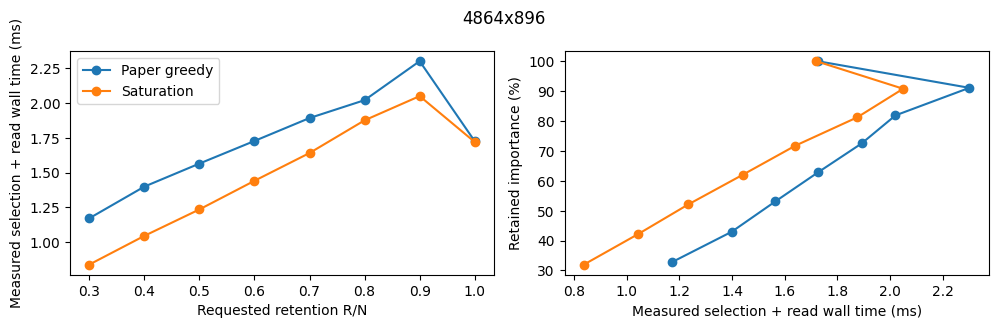

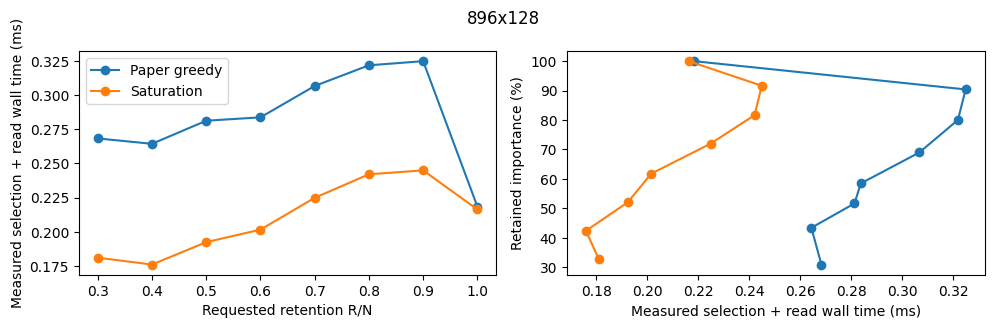

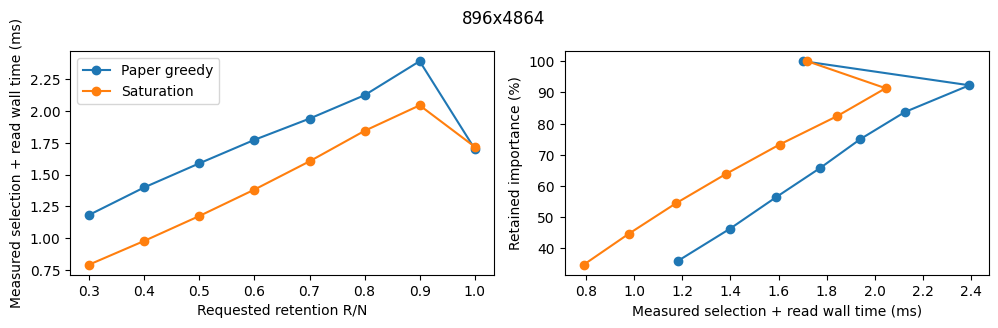

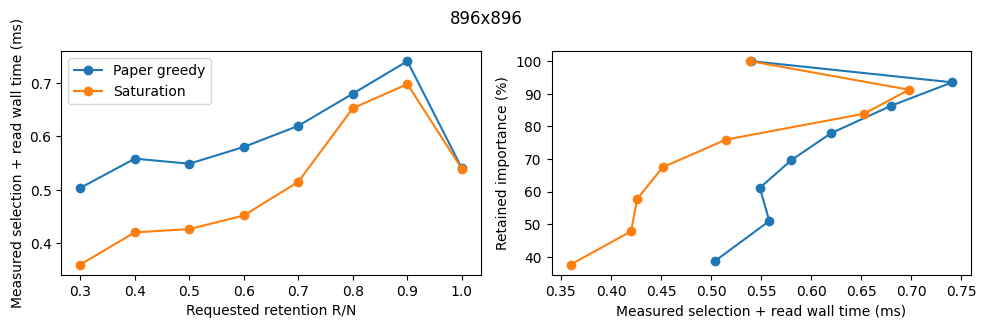

In [51]:
if not frame.empty:
    keys = ["shape", "trace_id", "fraction", "method"]
    cases = frame.groupby(keys)[["selection_ms","io_ms","wall_ms","retained_pct","fill_pct"]].median().reset_index()
    display(cases.groupby(["shape","method"])[["selection_ms","io_ms","wall_ms","fill_pct"]].median().round(4))
    for shape, group in cases.groupby("shape"):
        fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
        for name, data in group.groupby("method"):
            points = data.groupby("fraction")[["wall_ms","retained_pct"]].median()
            axes[0].plot(points.index, points.wall_ms, "o-", label=name)
            axes[1].plot(points.wall_ms, points.retained_pct, "o-", label=name)
        axes[0].set(xlabel="Requested retention R/N", ylabel="Measured selection + read wall time (ms)")
        axes[1].set(xlabel="Measured selection + read wall time (ms)", ylabel="Retained importance (%)")
        axes[0].legend()
        fig.suptitle(shape)
        plt.tight_layout()
        plt.show()

In [52]:
if not frame.empty:
    from scipy.stats import bootstrap
    intervals = []
    for shape, data in frame[np.isclose(frame.fraction, .5)].groupby("shape"):
        for name, group in data[data.trace_id == data.trace_id.min()].groupby("method"):
            for metric in ("selection_ms", "io_ms", "wall_ms"):
                sample = group[metric].to_numpy()
                ci = bootstrap((sample,), np.median, method="BCa", n_resamples=10000,
                               random_state=0).confidence_interval
                intervals.append(dict(shape=shape, trace_id=int(group.trace_id.iloc[0]), method=name,
                    metric=metric, median=np.median(sample), low=ci.low, high=ci.high))
    display(pd.DataFrame(intervals).set_index(["shape","trace_id","method","metric"]).round(4))

median     low    high
shape    trace_id method       metric                              
4864x896 6        Paper greedy selection_ms  0.4989  0.4748  0.5127
                               io_ms         1.0892  1.0741  1.1089
                               wall_ms       1.6599  1.6332  1.6835
                  Saturation   selection_ms  0.0446  0.0406  0.0503
                               io_ms         1.1791  1.1257  1.2094
                               wall_ms       1.2714  1.2366  1.3310
896x128  1        Paper greedy selection_ms  0.1050  0.1000  0.1095
                               io_ms         0.1594  0.1498  0.1742
                               wall_ms       0.2906  0.2841  0.3105
                  Saturation   selection_ms  0.0077  0.0071  0.0093
                               io_ms         0.1544  0.1483  0.1666
                               wall_ms       0.1852  0.1791  0.2071
896x4864 4        Paper greedy selection_ms  0.4889  0.4692  0.5379
                               io_ms         1.1539  1.1275  1.1735
                               wall_ms       1.6862  1.6562  1.7361
                  Saturation   selection_ms  0.0241  0.0203  0.0307
                               io_ms         1.2698  1.2039  1.3087
                               wall_ms       1.3368  1.2638  1.4107
896x896  0        Paper greedy selection_ms  0.3688  0.3536  0.3818
                               io_ms         0.3666  0.3538  0.4038
                               wall_ms       0.7682  0.7588  0.8118
                  Saturation   selection_ms  0.0126  0.0110  0.0147
                               io_ms         0.3677  0.3474  0.3892
                               wall_ms       0.4208  0.4060  0.4414

The profile guides selection; all plotted latencies are measured reads or enclosing wall time. Same-budget comparisons preserve Paper underfill. Full VLM accuracy and frame-forward latency require model integration beyond these saved importance vectors.

Sources: [01](../01/01_chunk_latency.ipynb), [02](../02/02_global_oracle.ipynb), [paper §3.1, §4, Appendix H](../../../../preliminary_research/2511.18692v1.pdf), [native reader](../../../upstream/vlm-flash/src/vlmflash/csrc/native.cc), [profiler](../../../upstream/vlm-flash/scripts/profile_flash.py).